In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("data/ev_stations.db")
df = pd.read_sql_query("SELECT * FROM utilization_forecast", conn)
conn.close()

df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 33264 entries, 0 to 33263
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   station_id            33264 non-null  int64  
 1   snapshot_time         33264 non-null  str    
 2   hour                  33264 non-null  int64  
 3   day_of_week           33264 non-null  int64  
 4   is_weekend            33264 non-null  int64  
 5   network               33264 non-null  str    
 6   total_ports           33264 non-null  int64  
 7   is_fast_charging_hub  33264 non-null  int64  
 8   fast_charger_ratio    33264 non-null  float64
 9   temperature           33264 non-null  float64
 10  humidity              33264 non-null  int64  
 11  wind_speed            33264 non-null  float64
 12  weather_condition     33264 non-null  str    
 13  utilization_rate      33264 non-null  float64
dtypes: float64(4), int64(7), str(3)
memory usage: 3.6 MB


station_id              0
snapshot_time           0
hour                    0
day_of_week             0
is_weekend              0
network                 0
total_ports             0
is_fast_charging_hub    0
fast_charger_ratio      0
temperature             0
humidity                0
wind_speed              0
weather_condition       0
utilization_rate        0
dtype: int64

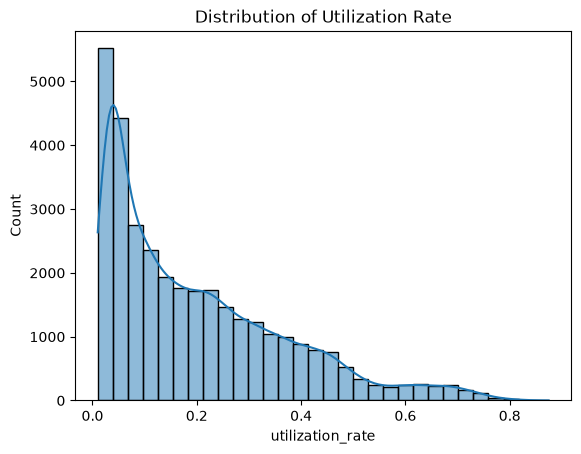

In [2]:
sns.histplot(df['utilization_rate'], bins = 30, kde = True)
plt.title("Distribution of Utilization Rate")
plt.show()

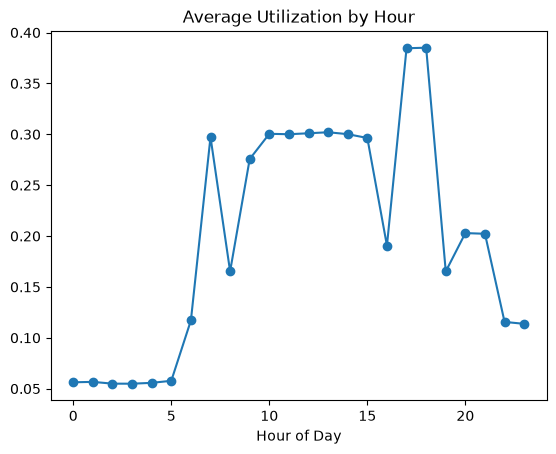

In [3]:
hourly_avg = df.groupby('hour')['utilization_rate'].mean()
hourly_avg.plot(kind = 'line', marker = 'o')
plt.title('Average Utilization by Hour')
plt.xlabel('Hour of Day')
plt.show()

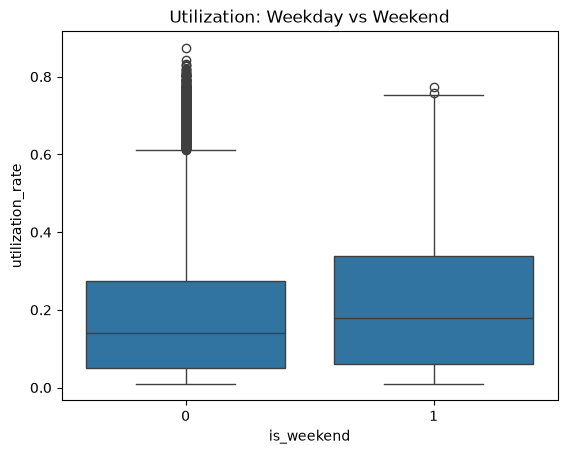

In [4]:
sns.boxplot(data = df, x = 'is_weekend', y = 'utilization_rate')
plt.title('Utilization: Weekday vs Weekend')
plt.show()

In [5]:
network_avg = df.groupby('network')['utilization_rate'].mean().sort_values(ascending = False)
print(network_avg)

network
Electrify America      0.328310
Tesla Destination      0.317210
Tesla                  0.244835
Blink Network          0.210879
ChargePoint Network    0.169300
ZEFNET                 0.160605
Non-Networked          0.057169
Name: utilization_rate, dtype: float64


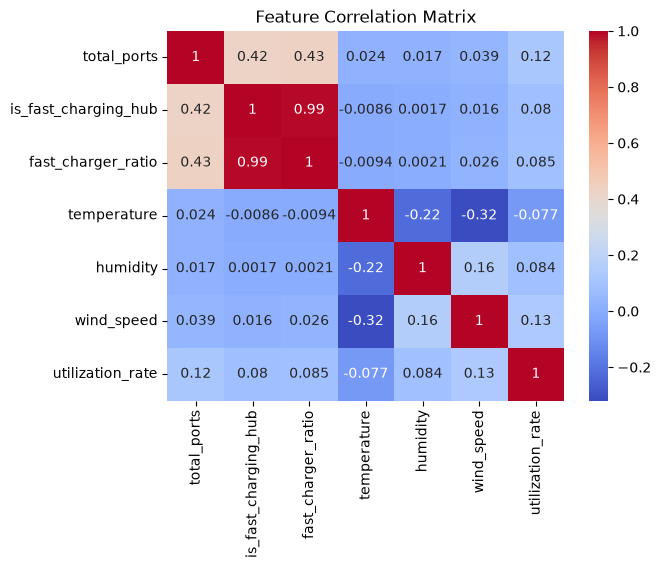

In [6]:
numeric_cols = ['total_ports',
                'is_fast_charging_hub',
                'fast_charger_ratio',
                'temperature',
                'humidity',
                'wind_speed',
                'utilization_rate']
sns.heatmap(df[numeric_cols].corr(), annot = True, cmap = 'coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_cols = ['hour',
                'day_of_week',
                'is_weekend',
                'total_ports',
                'is_fast_charging_hub',
                'fast_charger_ratio',
                'temperature',
                'humidity',
                'wind_speed',]

categorical_cols = ['network', 'weather_condition']

encoder = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

X = df[numeric_cols + categorical_cols]
y = df['utilization_rate']

In [8]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state = 0
)

X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

In [9]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

model = xgb.XGBRegressor(
    n_estimators = 200,
    max_depth = 5,
    learning_rate = 0.1,
    random_state = 0
)

model.fit(X_train_encoded, y_train)

preds = model.predict(X_test_encoded)

print(f"RMSE: {root_mean_squared_error(y_test, preds):.4f}")
print(f"MAE: {mean_absolute_error(y_test, preds):.4f}")
print(f"R^2: {r2_score(y_test, preds):.4f}")

RMSE: 0.0455
MAE: 0.0354
R^2: 0.9290


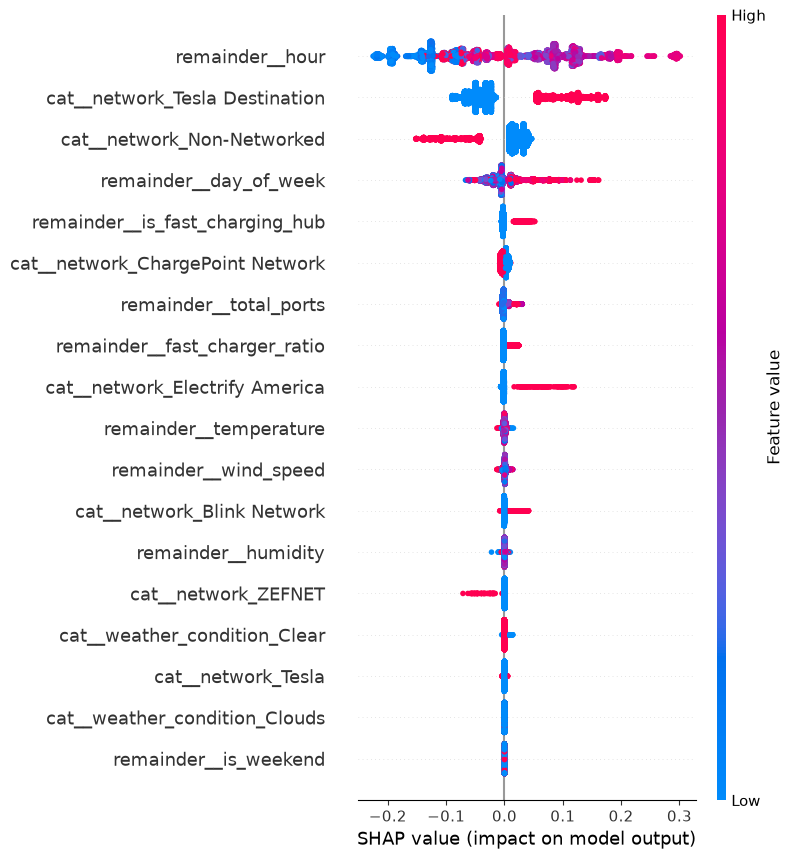

In [11]:
import shap

feature_names = encoder.get_feature_names_out()
X_test_df = pd.DataFrame(X_test_encoded, columns = feature_names)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_df)

shap.summary_plot(shap_values, X_test_df)

In [13]:
import pickle

with open("models/xgboost_ev_model.pkl", 'wb') as f:
    pickle.dump(model, f)

with open("models/encoder.pkl", 'wb') as f:
    pickle.dump(encoder, f)